In [ ]:
#SE DEBE CORRER PREVIAMENTE `pip install prophet` 
import pandas as pd
from prophet import Prophet
#kmeans(M) ; gaussian mixture(R) ; OPTICS(M) ; affinity(R) 



# Leer datos
df = pd.read_csv("datos_transformados.csv")

# Renombrar columnas
df = df.rename(columns={
    "Años__ESTANDAR": "ds",
    "value": "y"
})

# Fecha
df["ds"] = pd.to_datetime(df["ds"], format="%Y")

# Crear modelo
model = Prophet()

# Regresor extra
model.add_regressor("grupo_etario_ord")

# Entrenar
model.fit(df[["ds", "y", "grupo_etario_ord"]])

# Futuro
future = model.make_future_dataframe(periods=5, freq='Y')

# Necesitas también valores del regresor
future["grupo_etario_ord"] = 0

# Predicción
forecast = model.predict(future)

print(forecast[["ds", "yhat"]].tail())


01:09:16 - cmdstanpy - INFO - Chain [1] start processing
01:09:16 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat
21 2022-12-31   98.112451
22 2023-12-31  102.011332
23 2024-12-31  105.466404
24 2025-12-31  109.327985
25 2026-12-31  113.208282


C:\Users\darta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\prophet\forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


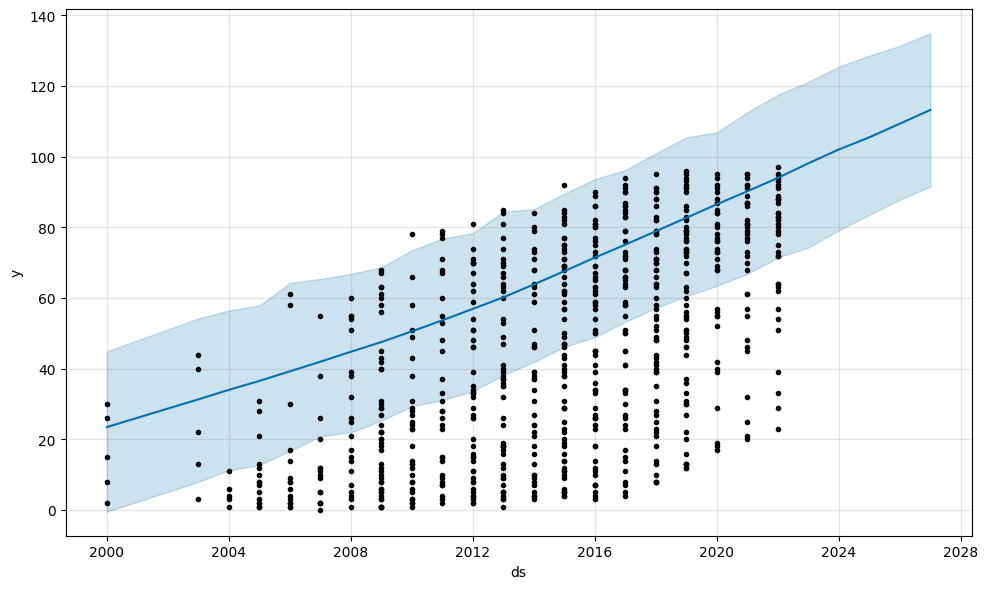

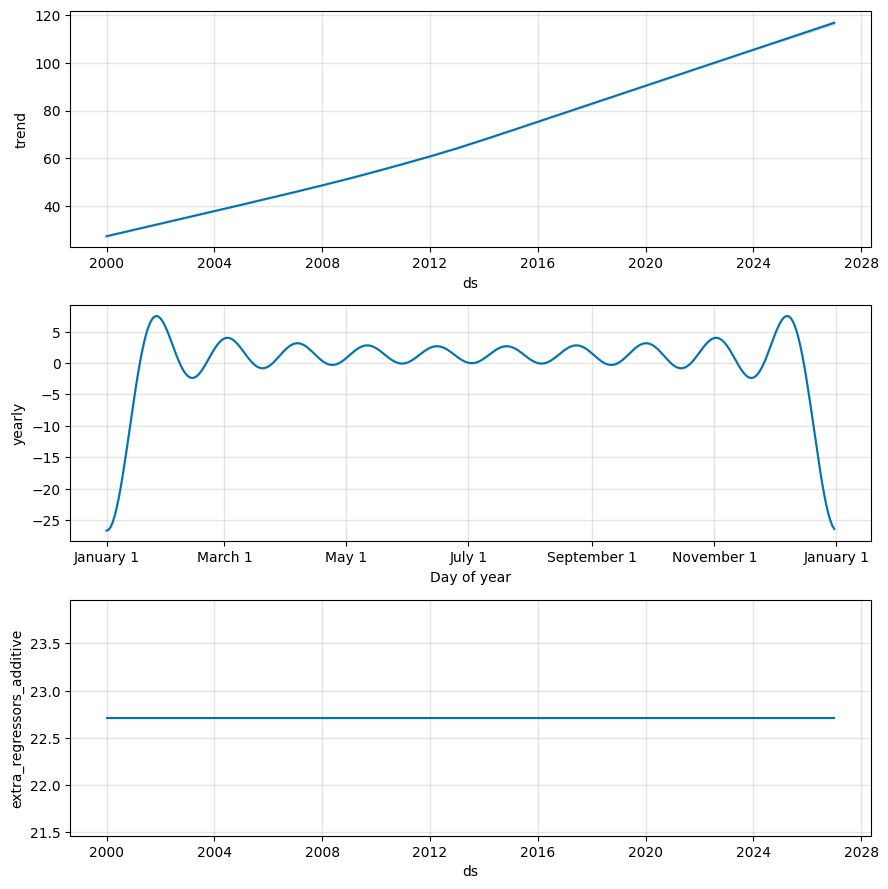

In [6]:

# m = Prophet()
# m.fit(df)
# future = m.make_future_dataframe(periods=365)
# future.tail()

# forecast = m.predict(future)
# forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)

